In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
def generate_synthetic_cate_data(n_samples=2000, random_seed=42):
    np.random.seed(random_seed)
    customer_sensitivity = np.random.uniform(0, 10, n_samples)
    discounts = np.random.binomial(1, 0.5, n_samples)
    true_cate = 2 + 0.5 * customer_sensitivity
    baseline_sales = 10 + customer_sensitivity
    noise = np.random.normal(0, 2, n_samples)
    sales = baseline_sales + (true_cate * discounts) + noise
    cate_pred = true_cate + np.random.normal(0, 1.5, n_samples)
    
    return pd.DataFrame({
        'sales': sales,
        'discounts': discounts,
        'cate_pred': cate_pred,
        'customer_sensitivity': customer_sensitivity,
        'true_cate': true_cate
    })

# Gerar o DF
df = generate_synthetic_cate_data()


In [ ]:
from toolz import curry

@curry
def effect(data, y, t):
        """Calcula o efeito médio do tratamento t sobre o resultado y.
        From the theory on simple linear regression, you know that:
β1
where 
=
t
∑ t i −t yi
∑ t i −t 2
        """
        return (np.sum((data[t] - data[t].mean())*data[y]) /
                np.sum((data[t] - data[t].mean())**2))

In [7]:
def effect_by_quantile(df, pred, y, t, q=10):
    
    # makes quantile partitions
    groups = np.round(pd.IntervalIndex(pd.qcut(df[pred], q=q)).mid, 2) 
    
    return (df
            .assign(**{f"{pred}_quantile": groups})
            .groupby(f"{pred}_quantile")
            # estimate the effect on each quantile
            .apply(effect(y=y, t=t), include_groups=False)) 

In [8]:
effect_by_quantiles = effect_by_quantile(
    df,
    pred="cate_pred",
    t="discounts",
    y="sales",
    q=10
)


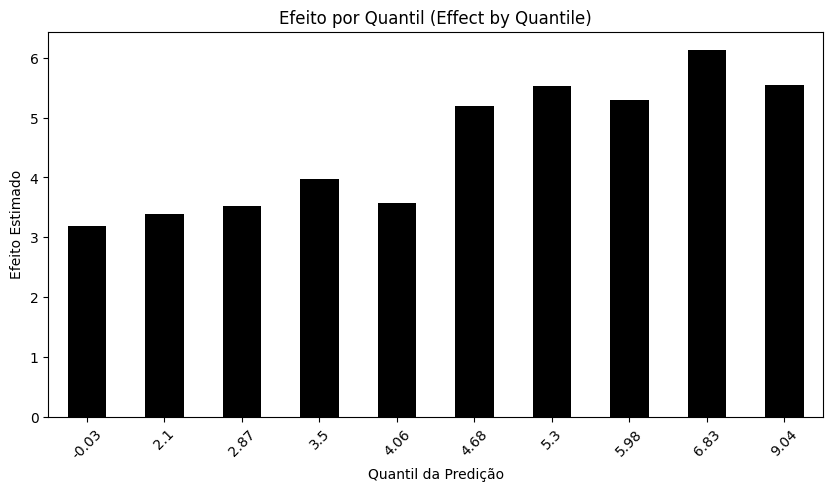

In [9]:
plt.figure(figsize=(10, 5))
effect_by_quantiles.plot(kind="bar", color="black")
plt.title("Efeito por Quantil (Effect by Quantile)")
plt.ylabel("Efeito Estimado")
plt.xlabel("Quantil da Predição")
plt.xticks(rotation=45)
plt.show()

In [10]:
effect(df, "sales", "discounts")

4.644688631246738

In [11]:
effect_by_quantiles

cate_pred_quantile
-0.03    3.183254
 2.10    3.393323
 2.87    3.526279
 3.50    3.974533
 4.06    3.569372
 4.68    5.192261
 5.30    5.523809
 5.98    5.294305
 6.83    6.128210
 9.04    5.539194
dtype: float64

In [12]:
def cumulative_effect_curve(dataset, prediction, y, t,
                            ascending=False, steps=100):
    size = len(dataset)
    ordered_df = (dataset
                  .sort_values(prediction, ascending=ascending)
                  .reset_index(drop=True))
    
    steps = np.linspace(size/steps, size, steps).round(0)
    
    return np.array([effect(ordered_df.query(f"index<={row}"), t=t, y=y)
                     for row in steps])

cumulative_effect_curve(df, "cate_pred", "sales", "discounts")

array([3.30047311, 4.71182123, 5.43228372, 5.22348088, 5.25847971,
       4.95914965, 5.45527847, 5.46106216, 5.46407974, 5.58925829,
       5.77239919, 5.87826355, 5.86790971, 5.92193458, 5.933429  ,
       5.88660184, 5.87555619, 5.93736174, 5.97131376, 5.88055594,
       5.90221155, 5.96039327, 5.99049306, 5.92178159, 5.92840523,
       5.92153126, 5.81812188, 5.74939234, 5.69307202, 5.69294551,
       5.6928731 , 5.69157839, 5.63217707, 5.61198891, 5.65395081,
       5.62112058, 5.58051609, 5.58768902, 5.58161347, 5.61946623,
       5.58065195, 5.53879448, 5.55565951, 5.59973298, 5.54455973,
       5.57454834, 5.59219581, 5.57227526, 5.49623783, 5.52332706,
       5.48255977, 5.42801946, 5.35575355, 5.32114265, 5.30558642,
       5.24389773, 5.18726745, 5.15091677, 5.15533363, 5.11111877,
       5.13947956, 5.12771245, 5.13606268, 5.10064411, 5.09129066,
       5.11042933, 5.05921499, 5.06796389, 5.08997604, 5.07240109,
       5.0537771 , 5.03111294, 5.04806634, 5.03256563, 5.03304

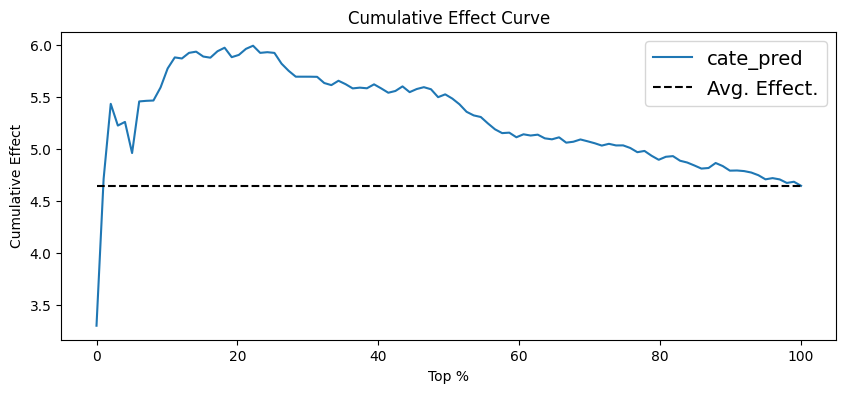

In [14]:
plt.figure(figsize=(10,4))

for m in ["cate_pred"]:
    cumu_effect = cumulative_effect_curve(df, m, "sales", "discounts", steps=100)
    x = np.array(range(len(cumu_effect)))
    plt.plot(100*(x/x.max()), cumu_effect, label=m)

plt.hlines(effect(df, "sales", "discounts"), 0, 100, linestyles="--", color="black", label="Avg. Effect.")
plt.xlabel("Top %")
plt.ylabel("Cumulative Effect")
plt.title("Cumulative Effect Curve")
plt.legend(fontsize=14)

In [15]:
def cumulative_gain_curve(df, prediction, y, t,
                          ascending=False, normalize=False, steps=100):
    
    effect_fn = effect(t=t, y=y)
    normalizer = effect_fn(df) if normalize else 0
    
    size = len(df)
    ordered_df = (df
                  .sort_values(prediction, ascending=ascending)
                  .reset_index(drop=True))
    
    steps = np.linspace(size/steps, size, steps).round(0)
    effects = [(effect_fn(ordered_df.query(f"index<={row}"))
                -normalizer)*(row/size) 
               for row in steps]

    return np.array([0] + effects)


cumulative_gain_curve(df, "cate_pred", "sales", "discounts")

array([0.        , 0.03300473, 0.09423642, 0.16296851, 0.20893924,
       0.26292399, 0.29754898, 0.38186949, 0.43688497, 0.49176718,
       0.55892583, 0.63496391, 0.70539163, 0.76282826, 0.82907084,
       0.89001435, 0.94185629, 0.99884455, 1.06872511, 1.13454961,
       1.17611119, 1.23946443, 1.31128652, 1.3778134 , 1.42122758,
       1.48210131, 1.53959813, 1.57089291, 1.60982986, 1.65099089,
       1.70788365, 1.76479066, 1.82130508, 1.85861843, 1.90807623,
       1.97888278, 2.02360341, 2.06479095, 2.12332183, 2.17682925,
       2.24778649, 2.2880673 , 2.32629368, 2.38893359, 2.46388251,
       2.49505188, 2.56429224, 2.62833203, 2.67469212, 2.69315654,
       2.76166353, 2.79610548, 2.82257012, 2.83854938, 2.87341703,
       2.91807253, 2.93658273, 2.95674245, 2.98753173, 3.04164684,
       3.06667126, 3.13508253, 3.17918172, 3.23571949, 3.26441223,
       3.30933893, 3.37288336, 3.38967404, 3.44621545, 3.51208347,
       3.55068076, 3.58818174, 3.62240132, 3.68508843, 3.72409

Text(0.5, 1.0, 'Cumulative Gain Curve (Normalized)')

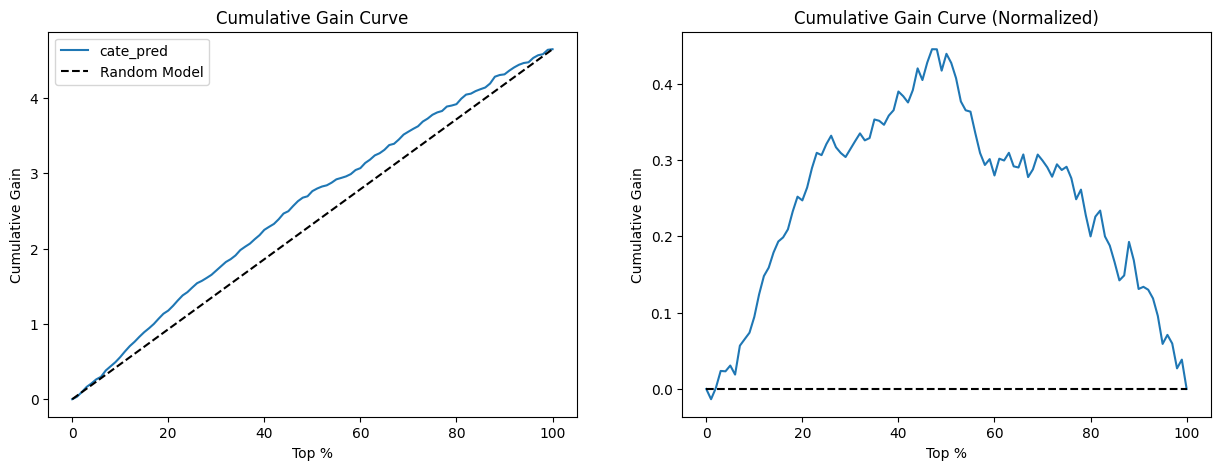

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5))

for m in ["cate_pred"]:
    cumu_gain = cumulative_gain_curve(df, m, "sales", "discounts")
    x = np.array(range(len(cumu_gain)))
    ax1.plot(100*(x/x.max()), cumu_gain, label=m)
    
ax1.plot([0, 100], [0, effect(df, "sales", "discounts")], linestyle="--", label="Random Model", color="black")

ax1.set_xlabel("Top %")
ax1.set_ylabel("Cumulative Gain")
ax1.set_title("Cumulative Gain Curve")
ax1.legend()


for m in ["cate_pred"]:
    cumu_gain = cumulative_gain_curve(df, m, "sales", "discounts", normalize=True)
    x = np.array(range(len(cumu_gain)))
    ax2.plot(100*(x/x.max()), cumu_gain, label=m)
    
ax2.hlines(0, 0, 100, linestyle="--", label="Random Model", color="black")

ax2.set_xlabel("Top %")
ax2.set_ylabel("Cumulative Gain")
ax2.set_title("Cumulative Gain Curve (Normalized)")

In [20]:
gain = cumulative_gain_curve(df, "cate_pred",
                                 "sales", "discounts", normalize=True)
auc = np.sum(gain)

In [21]:
auc

24.634030848378384